# 01 : Exploration des données (EDA) - CMS Open Payments

**Dataset** : CMS Open Payments (General Payments)
**Source** : US Centers for Medicare & Medicaid Services, données publiques via API
**Périmètre** : Virginie-Occidentale (WV), années 2022 et 2023
**Volume brut** : ~186 000 paiements

---

## Contexte

Aux États-Unis, la loi (Sunshine Act) oblige les laboratoires à déclarer publiquement chaque paiement ou avantage versé à un professionnel de santé (repas, voyage, conseil, orateur, formation). Une ligne = un paiement. C'est le jeu de référence sur la relation commerciale industrie / professionnels de santé.

## Objectif de ce notebook

**Regarder la donnée brute avant toute transformation.** On charge le brut, on observe (structure, types, valeurs manquantes, distributions, spécialités, laboratoires, piste de la cible de rétention), et on **conclut par les décisions de préparation** qui seront appliquées au notebook 02. On ne prépare pas des données qu'on n'a pas explorées.

## 0. Chargement des données brutes (API CMS)

On récupère les paiements bruts des deux années via l'API CMS (pagination par 500, filtrage serveur sur l'État), on garde les colonnes utiles **sans les transformer**, et on sauvegarde le brut dans `payments_raw` (le notebook 02 repartira de là, sans re-télécharger).

In [1]:
import sqlite3, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import requests

API = "https://openpaymentsdata.cms.gov/api/1"
STATE = "WV"; YEARS = [2022, 2023]
DATASET_IDS = {2022: "df01c2f8-dc1f-4e79-96cb-8208beaf143c",
               2023: "fb3a65aa-c901-4a38-a813-b04b00dfa2a9"}
KEEP = ["covered_recipient_profile_id", "covered_recipient_type", "recipient_state",
        "covered_recipient_specialty_1",
        "applicable_manufacturer_or_applicable_gpo_making_payment_name",
        "total_amount_of_payment_usdollars", "nature_of_payment_or_transfer_of_value", "program_year"]
PAGE = 500  # l'API CMS plafonne limit a 500

ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().parent / "data").exists() else pathlib.Path.cwd()
DB_PATH = ROOT / "data" / "openpayments.sqlite"

def fetch_state_year(year, state):
    url = f"{API}/datastore/query/{DATASET_IDS[year]}/0"
    rows, offset, total = [], 0, None
    while True:
        params = {"limit": PAGE, "offset": offset, "conditions[0][property]": "recipient_state",
                  "conditions[0][value]": state, "conditions[0][operator]": "="}
        payload = requests.get(url, params=params, timeout=120).json()
        batch = payload.get("results", [])
        if total is None:
            total = payload.get("count", 0); print(f"  {year}/{state}: {total} lignes")
        if not batch:
            break
        rows.extend(batch); offset += len(batch)
        if offset >= total:
            break
    return pd.DataFrame(rows)[[c for c in KEEP if c in pd.DataFrame(rows).columns]].copy()

raw = pd.concat([fetch_state_year(y, STATE) for y in YEARS], ignore_index=True)
DB_PATH.parent.mkdir(parents=True, exist_ok=True)
with sqlite3.connect(DB_PATH) as con:
    raw.to_sql("payments_raw", con, if_exists="replace", index=False)
print("Donnees brutes :", raw.shape)

  2022/WV: 90294 lignes


  2023/WV: 96132 lignes


Donnees brutes : (186426, 8)


## 1. Aperçu général

`head()` pour voir à quoi ressemble une ligne, et les **types** : dans le brut, tout arrive en texte (l'API renvoie des chaines).

In [2]:
display(raw.head())
raw.dtypes

,covered_recipient_profile_id,covered_recipient_type,recipient_state,covered_recipient_specialty_1,applicable_manufacturer_or_applicable_gpo_making_payment_name,total_amount_of_payment_usdollars,nature_of_payment_or_transfer_of_value,program_year
0,11129614,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,ZOLL Services LLC (A/K/A ZOLL LifeCor Corp),11.23,Food and Beverage,2022
1,10620312,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,ZOLL Services LLC (A/K/A ZOLL LifeCor Corp),9.75,Food and Beverage,2022
2,11004046,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,ZOLL Services LLC (A/K/A ZOLL LifeCor Corp),7.31,Food and Beverage,2022
3,11129614,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,BRACCO DIAGNOSTICS INC.,18.56,Food and Beverage,2022
4,10429903,Covered Recipient Non-Physician Practitioner,WV,Physician Assistants & Advanced Practice Nursi...,Tactile Systems Technology Inc,19.38,Food and Beverage,2022


covered_recipient_profile_id                                     object
covered_recipient_type                                           object
recipient_state                                                  object
covered_recipient_specialty_1                                    object
applicable_manufacturer_or_applicable_gpo_making_payment_name    object
total_amount_of_payment_usdollars                                object
nature_of_payment_or_transfer_of_value                           object
program_year                                                     object
dtype: object

> **Observation.** Tout est en `object` (texte), y compris le **montant** et l'**année** : il faudra les convertir en numérique. La spécialité (`covered_recipient_specialty_1`) est un champ **hiérarchique** séparé par `|` (ex. `...|Nurse Practitioner|Family`) : on en extraira le niveau haut.

## 2. Valeurs manquantes

In [3]:
manquants = pd.DataFrame({"manquants": raw.isna().sum(),
                          "vides": (raw == "").sum()})
manquants["% total"] = (100 * (manquants["manquants"] + manquants["vides"]) / len(raw)).round(1)
manquants

,manquants,vides,% total
covered_recipient_profile_id,0,203,0.1
covered_recipient_type,0,0,0.0
recipient_state,0,0,0.0
covered_recipient_specialty_1,0,203,0.1
applicable_manufacturer_or_applicable_gpo_making_payment_name,0,0,0.0
total_amount_of_payment_usdollars,0,0,0.0
nature_of_payment_or_transfer_of_value,0,0,0.0
program_year,0,0,0.0


> **Observation.** Le champ clé `covered_recipient_profile_id` est **manquant pour certaines lignes** : ce sont les paiements aux **hôpitaux universitaires** (pas des professionnels individuels). Comme l'analyse porte sur les professionnels de santé, ces lignes seront exclues. Les montants ne sont pas manquants.

## 3. Distribution des montants et de l'engagement

Pour visualiser, on convertit temporairement le montant en numérique (la conversion "officielle" se fera en préparation). On tronque au 99e centile pour la lisibilité.

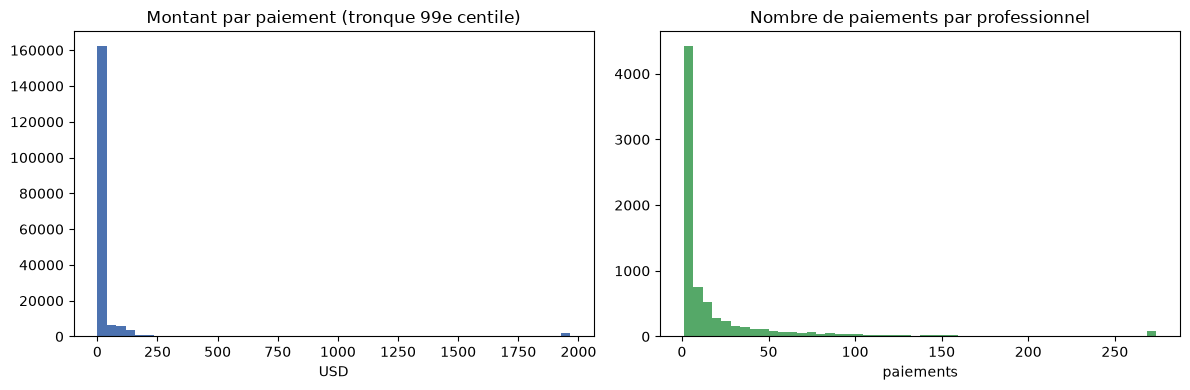

In [4]:
montant = pd.to_numeric(raw["total_amount_of_payment_usdollars"], errors="coerce")
par_hcp = raw.dropna(subset=["covered_recipient_profile_id"]).groupby("covered_recipient_profile_id").size()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(montant.clip(upper=montant.quantile(0.99)), bins=50, color="#4C72B0")
ax[0].set_title("Montant par paiement (tronque 99e centile)"); ax[0].set_xlabel("USD")
ax[1].hist(par_hcp.clip(upper=par_hcp.quantile(0.99)), bins=50, color="#55A868")
ax[1].set_title("Nombre de paiements par professionnel"); ax[1].set_xlabel("paiements")
plt.tight_layout(); plt.show()

> **Observation.** Fortes asymétries (lois de puissance) : beaucoup de petits paiements, quelques très gros ; beaucoup de HCP peu sollicités, une minorité très sollicitée. Pour le modèle, il faudra **standardiser** ces variables, et l'**agrégation au niveau du professionnel** est le bon grain d'analyse.

## 4. Natures de paiement, spécialités, laboratoires

C:\Users\Juliette Vanessa\AppData\Local\Temp\ipykernel_18328\507760719.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(); plt.show()


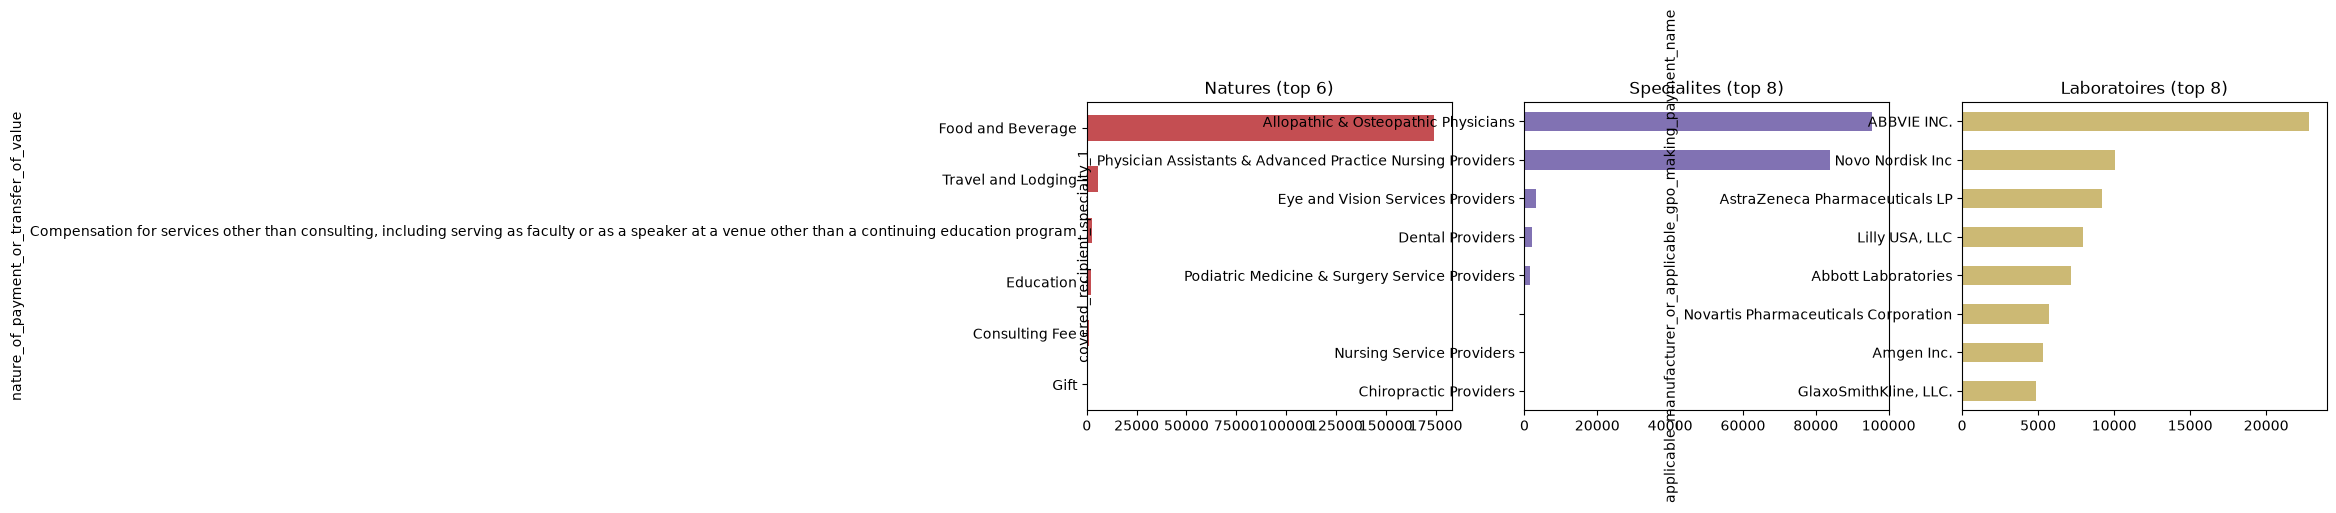

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
raw["nature_of_payment_or_transfer_of_value"].value_counts().head(6).plot.barh(ax=ax[0], color="#C44E52"); ax[0].set_title("Natures (top 6)"); ax[0].invert_yaxis()
raw["covered_recipient_specialty_1"].str.split("|").str[0].value_counts().head(8).plot.barh(ax=ax[1], color="#8172B3"); ax[1].set_title("Specialites (top 8)"); ax[1].invert_yaxis()
raw["applicable_manufacturer_or_applicable_gpo_making_payment_name"].value_counts().head(8).plot.barh(ax=ax[2], color="#CCB974"); ax[2].set_title("Laboratoires (top 8)"); ax[2].invert_yaxis()
plt.tight_layout(); plt.show()

> **Observation.** **Food and Beverage** (repas) domine très largement. Les spécialités dominantes sont médecins et professions infirmières avancées. Côté laboratoires, on repère un **problème de qualité** : les noms ne sont pas normalisés (« ABBVIE INC. » vs « AbbVie Inc. » comptés séparément) - à signaler en gouvernance.

## 5. Structure : paiements vs professionnels

In [6]:
print("lignes (paiements)        :", len(raw))
print("professionnels identifies :", raw["covered_recipient_profile_id"].nunique())
print("lignes sans identifiant   :", int(raw["covered_recipient_profile_id"].isna().sum()))
print("\nType de beneficiaire :")
print(raw["covered_recipient_type"].value_counts())

lignes (paiements)        : 186426
professionnels identifies : 7754
lignes sans identifiant   : 0

Type de beneficiaire :
covered_recipient_type
Covered Recipient Physician                     102310
Covered Recipient Non-Physician Practitioner     83913
Covered Recipient Teaching Hospital                203
Name: count, dtype: int64


> **Observation.** Il y a **beaucoup plus de paiements que de professionnels** : il faudra passer du grain "paiement" au grain "professionnel" par agrégation. Les lignes sans identifiant correspondent aux **hôpitaux universitaires**, à exclure de l'analyse HCP.

## 6. Vers la cible : la rétention 2022 → 2023

Idée du projet : un professionnel engagé (payé) en 2022 le sera-t-il encore en 2023 ? On mesure le recouvrement des professionnels entre les deux années.

In [7]:
annee = pd.to_numeric(raw["program_year"], errors="coerce")
ids_2022 = set(raw.loc[annee == 2022, "covered_recipient_profile_id"].dropna())
ids_2023 = set(raw.loc[annee == 2023, "covered_recipient_profile_id"].dropna())
retention = len(ids_2022 & ids_2023) / len(ids_2022)
print(f"Professionnels payes en 2022 : {len(ids_2022)}")
print(f"Encore payes en 2023         : {len(ids_2022 & ids_2023)}")
print(f"=> Taux de retention          : {retention:.1%}")

Professionnels payes en 2022 : 5708
Encore payes en 2023         : 4185
=> Taux de retention          : 73.3%


> **Observation.** ~**73 %** des professionnels payés en 2022 le sont encore en 2023 : une cible **exploitable mais déséquilibrée** (majorité de "retenus"). Ce sera la variable à prédire, construite en préparation.

## 7. Décisions de préparation

À appliquer au **notebook 02**, d'après ce qu'on vient d'observer :

1. **Convertir** `total_amount_of_payment_usdollars` et `program_year` en numérique.
2. **Extraire** le niveau haut de la spécialité (`covered_recipient_specialty_1`, séparateur `|`).
3. **Exclure** les lignes sans `covered_recipient_profile_id` (hôpitaux universitaires, hors périmètre HCP individuel).
4. **Agréger au niveau du professionnel** (année 2022) : nombre de paiements, montant total et moyen, nombre de laboratoires, nombre de natures, part de chaque nature de paiement.
5. **Construire la cible** `retenu` : le professionnel de 2022 reçoit-il au moins un paiement en 2023 ? (features en N, cible en N+1 : pas de fuite temporelle).
6. **Ne pas normaliser** les noms de laboratoires pour l'instant (problème repéré) mais le **documenter en gouvernance** (hors périmètre du modèle de rétention).